# Phase 1.5 1a — Engine-1a Default Run (A.1, Q-only e5)

End-to-end pipeline for the **A.1 default** ablation row (paper §7.4):
- LogiQA 2.0 + ReClor corpus build
- Q-only e5-large-v2 encoding
- Stage 0 raw-encoder ceiling (F2 sanity)
- Train Phase15MoE (K=128, K_active target=4)
- 4-control selectivity gate + 1σ bootstrap
- Engineering report (k_active mean, dead-expert frac, training curves)

**Runtime estimate**: ~2h Colab T4 / 40min A100 at 20K train samples.

**FAIL fallback** (paper §7.4): if A.1 fails, branch to A.2/A.3 strict-control ladder
(notebook ``02_ablations.ipynb``) and the encoder-swap row C, per the FAIL diagnostic
in the plan.

## 1. Setup (Colab Drive mount + sys.path + GPU)

In [1]:
import os, sys
from pathlib import Path

BASE = Path('/content/drive/MyDrive/sideproject')
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

if str(BASE) not in sys.path:
    sys.path.insert(0, str(BASE))

print(f'BASE = {BASE}')

Mounted at /content/drive
BASE = /content/drive/MyDrive/sideproject


In [2]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device = {device}')
if torch.cuda.is_available():
    print(f'GPU = {torch.cuda.get_device_name(0)}, compute capability = {torch.cuda.get_device_capability(0)}')

device = cuda
GPU = NVIDIA A100-SXM4-40GB, compute capability = (8, 0)


## 2. Corpus build + reasoning-type histogram

In [3]:
from phase1_5.data import MCCorpusConfig, build_mc_corpus

cfg = MCCorpusConfig(
    max_train_samples=20_000,
    max_val_samples=2_000,
    max_test_samples=2_000,
    t_cap_q=128,
    t_cap_p=256,
    cache_root=str(BASE / 'out' / 'phase1_5' / 'cache'),
)
corpus = build_mc_corpus(cfg)
print(corpus.groupby(['source', 'split']).size().unstack(fill_value=0))
print('\nreasoning-type histogram:')
print(corpus['reasoning_type'].value_counts().head(20))

[corpus] reusing cache: /content/drive/MyDrive/sideproject/out/phase1_5/cache/corpus_86826446eb.parquet
split    test  train   val
source                    
logiqa2  1572  12567  1521
reclor      0   4638   479

reasoning-type histogram:
reasoning_type
sufficient_conditional    14886
other                      2099
flaw                        725
assumption                  591
conjunctive                 491
weaken                      453
strengthen                  391
inference                   388
paradox                     181
disjunctive                 145
principle                   111
main_point                  105
categorical                  93
method                       60
evaluate                     32
parallel                     26
Name: count, dtype: int64


## 3. Encoding — A.1 Q-only e5-large-v2

In [4]:
from phase1_5.data import MODE_Q_ONLY, encode_or_load_mc

data = encode_or_load_mc(corpus, cfg, encoding_mode=MODE_Q_ONLY, batch_size=32, device=device)
for k, v in data.items():
    try:
        print(f'{k:20s} shape={v.shape} dtype={v.dtype}')
    except AttributeError:
        print(f'{k:20s} (no shape)')

[encode] reusing cache: q_tok_intfloat_e5-large-v2_T128_Q_only_p2d5312_54e97c805b.npy + p + cand
q_tokens             shape=(20777, 128, 1024) dtype=float16
q_mask               shape=(20777, 128) dtype=int8
p_tokens             shape=(20777, 256, 1024) dtype=float16
p_mask               shape=(20777, 256) dtype=int8
cand_pooled          shape=(20777, 4, 1024) dtype=float32
answer_idx           shape=(20777,) dtype=int64
reasoning_type       shape=(20777,) dtype=object
source               shape=(20777,) dtype=object
split                shape=(20777,) dtype=object


## 4. Stage 0 raw-encoder ceiling check (F2 sanity)

Paper §1.1 + plan FAIL fallback: if raw e5 cannot decode operation above random+geometry,
the bottleneck experiment is moot — the encoder lacks the signal. PASS expected per
the Phase 1 Stage 1 ceiling 0.60 evidence (verified at academic-pipeline Stage 4.5).

In [5]:
import numpy as np

from phase1_5.eval import make_phase15_controls, raw_embedding_report
from phase1_5.data import infer_reasoning_type

# Probe split: test 우선, 없으면 val. ReClor test = hidden label, LogiQA 2.0 일부
# 미러도 test answer 비어 row drop → 'test' 가 0개일 수 있음.
for ps in ('test', 'val', 'train'):
    if (data['split'] == ps).any():
        probe_split = ps
        break
else:
    raise RuntimeError('no usable probe split (all empty)')

print(f'probe split = {probe_split}')
print('split distribution:', {s: int((data["split"] == s).sum()) for s in ('train', 'val', 'test')})

probe_mask = data['split'] == probe_split
probe_q_tokens = data['q_tokens'][probe_mask].astype(np.float32)
probe_q_mask = data['q_mask'][probe_mask].astype(np.float32)
probe_labels = np.asarray(data['reasoning_type'])[probe_mask]
probe_corpus = corpus[corpus['split'] == probe_split].reset_index(drop=True)

# Stale-cache fallback: ReClor metaeval mirror 에 question_type 없음 → cache 가
# 모두 'unknown' 으로 채워진 채 빌드되었으면 단일 클래스. Question 의 LSAT-style
# stem regex 로 inline 재 infer. engine_1a.run_engine_1a 도 같은 fallback 갖고
# 있으므로 cell-11 의 production 경로도 보호됨.
if len(set(probe_labels)) < 2:
    print(f'[fallback] reasoning_type = single class ({set(probe_labels)}); re-inferring from question text')
    probe_labels = np.array([infer_reasoning_type(q) for q in probe_corpus['question'].tolist()])

print(f'probe rows = {len(probe_labels)} | reasoning_types:')
import collections
for t, c in collections.Counter(probe_labels).most_common():
    print(f'  {t:15s} {c}')

controls0 = make_phase15_controls(probe_corpus['question'].tolist(), probe_corpus['passage'].tolist())
stage0 = raw_embedding_report(
    probe_q_tokens, probe_q_mask, probe_labels,
    control_label_sets={'topic': controls0['topic'], 'token': controls0['token']},
    agg='meanmax', seed=0,
)
print('\nStage 0 verdict:', stage0['verdict'])
print(f'adj_operation = {stage0["adj_operation"]:.4f}')
print('controls:')
for name, adj in stage0['adj_controls'].items():
    print(f'  adj_{name:10s} = {adj:.4f}')
if stage0['warnings']:
    print('warnings:', stage0['warnings'])

probe split = test
split distribution: {'train': 17205, 'val': 2000, 'test': 1572}
probe rows = 1572 | reasoning_types:
  sufficient_conditional 1491
  conjunctive     47
  disjunctive     18
  categorical     12
  other           3
  assumption      1

Stage 0 verdict: FAIL
adj_operation = 0.0000
controls:
  adj_random     = 0.0000
  adj_topic      = 0.2146
  adj_geometry   = 0.0000
warnings: ["control 'token' skipped: <2 classes (degenerate)"]


## 5. Run engine_1a (A.1 default)

In [6]:
from phase1_5.ablations import PHASE1_5_INITIAL_ROWS, run_ablation_row
from phase1_5.train import TrainConfig

A1 = PHASE1_5_INITIAL_ROWS[0]
print('Row:', A1)

train_cfg = TrainConfig(epochs=40, lr=1e-3, k_target=4.0, seed=0)
result = run_ablation_row(
    A1,
    corpus_cfg=cfg,
    train_cfg=train_cfg,
    out_dir=str(BASE / 'out' / 'phase1_5' / 'ablations'),
    device=device,
    seed=0,
    batch_size=64,
    skip_if_exists=True,
    progress=True,
)
gate = result['gate']
print('\n--- gate verdict ---')
print(f'verdict          = {gate.get("verdict")}')
print(f'adj_operation    = {gate.get("adj_operation"):.4f}')
print(f'σ(adj_op)        = {gate.get("sigma_adj_operation"):.4f}')
print(f'threshold        = {gate.get("threshold"):.4f}')
print(f'passes σ gate    = {gate.get("passes_sigma_gate")}')
print('controls:')
for name, adj in (gate.get('adj_controls') or {}).items():
    print(f'  adj_{name:10s} = {adj:.4f}')

Row: AblationRow(row_id='A.1', name='Q-only default', encoding_mode='Q_only', encoder_name='intfloat/e5-large-v2', modulation='kg_hypernet', k_routed=64, k_active_target=4.0, lb_strategy='aux_free', notes='Default — Q-only encoding under e5-large-v2 + cross-attn modulation + aux-free LB + K=64.')
[ablation] ▶ A.1 'Q-only default' (seed=0, device=cuda)
[corpus] reusing cache: /content/drive/MyDrive/sideproject/out/phase1_5/cache/corpus_86826446eb.parquet
[encode] reusing cache: q_tok_intfloat_e5-large-v2_T128_Q_only_p2d5312_54e97c805b.npy + p + cand


train_phase15:   0%|          | 0/40 [00:00<?, ?it/s]

[train] ep=  0 loss=1.3543 ce=1.3543 acc=0.333 k_active=63.72 lam=0.00000 (warmup) val_loss=1.3387 val_acc=0.323
[train] ep=  1 loss=1.3209 ce=1.3209 acc=0.357 k_active=62.71 lam=0.00000 (warmup) val_loss=1.3401 val_acc=0.342
[train] ep=  2 loss=1.3038 ce=1.3038 acc=0.361 k_active=46.88 lam=0.00000 (warmup) val_loss=1.3229 val_acc=0.349
[train] ep=  3 loss=1.2973 ce=1.2969 acc=0.372 k_active=20.94 lam=0.00017 val_loss=1.3259 val_acc=0.328
[train] ep=  4 loss=1.2718 ce=1.2717 acc=0.384 k_active=9.23 lam=0.00021 val_loss=1.3183 val_acc=0.349
[train] ep=  5 loss=1.2478 ce=1.2477 acc=0.397 k_active=8.02 lam=0.00025 val_loss=1.3129 val_acc=0.346
[train] ep=  6 loss=1.2233 ce=1.2232 acc=0.418 k_active=6.14 lam=0.00030 val_loss=1.3041 val_acc=0.368
[train] ep=  7 loss=1.1842 ce=1.1840 acc=0.450 k_active=5.14 lam=0.00036 val_loss=1.3374 val_acc=0.379
[train] ep=  8 loss=1.1459 ce=1.1457 acc=0.472 k_active=5.00 lam=0.00043 val_loss=1.3171 val_acc=0.388
[train] ep=  9 loss=1.0985 ce=1.0982 acc=0

## 6. Training curves + engineering report

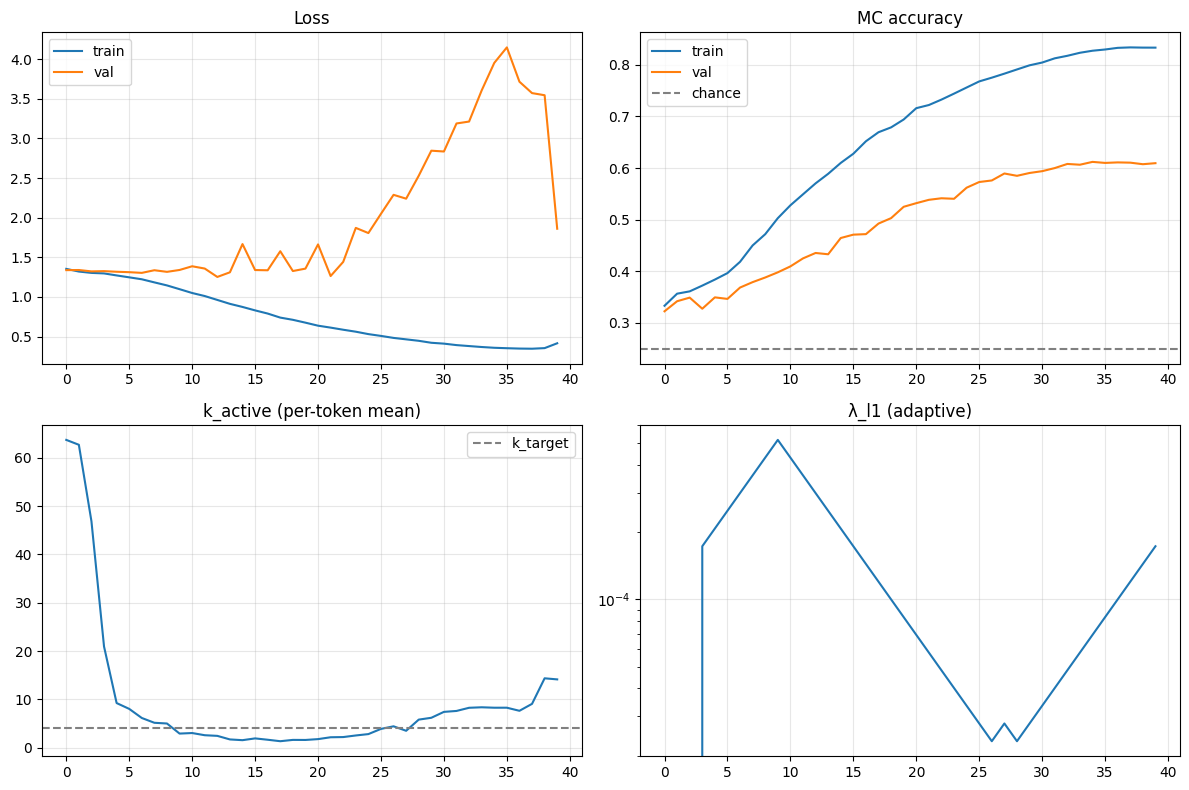


final k_active (token-weighted) = 14.13
dead expert fraction            = 0.953  (61/64)


In [7]:
import matplotlib.pyplot as plt
import numpy as np

history = result['history']
epochs = [h['epoch'] for h in history]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(epochs, [h['loss'] for h in history], label='train')
if 'val_loss' in history[0]:
    axes[0, 0].plot(epochs, [h['val_loss'] for h in history], label='val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, [h['mc_acc'] for h in history], label='train')
if 'val_mc_acc' in history[0]:
    axes[0, 1].plot(epochs, [h['val_mc_acc'] for h in history], label='val')
axes[0, 1].axhline(0.25, color='gray', linestyle='--', label='chance')
axes[0, 1].set_title('MC accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, [h['k_active_mean'] for h in history])
axes[1, 0].axhline(4, color='gray', linestyle='--', label='k_target')
axes[1, 0].set_title('k_active (per-token mean)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, [h['lam_l1'] for h in history])
axes[1, 1].set_title('λ_l1 (adaptive)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

eng = result['engineering']
print(f'\nfinal k_active (token-weighted) = {eng["k_active_mean_token_weighted"]:.2f}')
print(f'dead expert fraction            = {eng["dead_expert_frac"]:.3f}  ({int(eng["dead_expert_frac"]*eng["k_routed"])}/{eng["k_routed"]})')

## 7. Per-expert load histogram

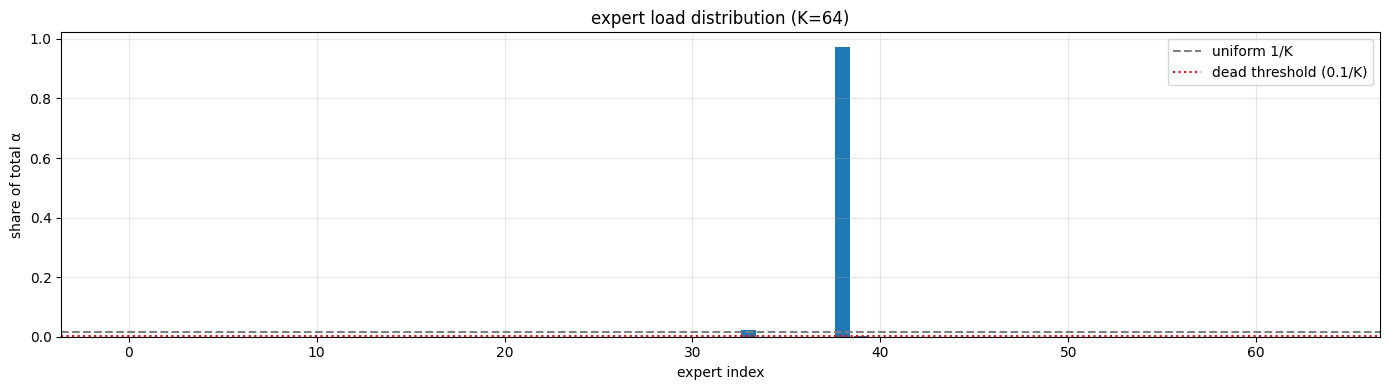

In [8]:
import matplotlib.pyplot as plt
import numpy as np

p_k = np.asarray(eng['expert_load_distribution'])
k = eng['k_routed']
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(k), p_k)
ax.axhline(1 / k, color='gray', linestyle='--', label='uniform 1/K')
ax.axhline(0.1 / k, color='red', linestyle=':', label='dead threshold (0.1/K)')
ax.set_xlabel('expert index')
ax.set_ylabel('share of total α')
ax.set_title(f'expert load distribution (K={k})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Verdict summary

- **PASS** ⇒ proceed to ``02_ablations.ipynb`` for the A.1/A.2/A.3 strict-control ladder.
- **FAIL + Stage 0 ceiling chance** ⇒ F2 (encoder fault), branch to Row C (BGE swap).
- **FAIL + Stage 0 ceiling PASS** ⇒ F3 (new collapse mode despite operation-axis recoverability), open diagnostic round.
- **PASS + A.2 ≫ A.1** (later ladder) ⇒ Q-only bottleneck attribution failed (position-mask suspicious).
- **PASS + A.1 ≈ A.3** (later ladder) ⇒ bottleneck has no effect (full-P encoding shows no gain).

Decision rules per paper §7.4 + the plan's FAIL diagnostic ladder.

In [10]:
import json, glob
from pathlib import Path
if 'BASE' not in dir(): BASE = Path('/content/drive/MyDrive/sideproject')
paths = sorted(glob.glob(str(BASE/'out'/'phase1_5'/'ablations'/'row_A.1_seed0_*.json')))
print("found:", [Path(p).name for p in paths])
d = json.load(open(paths[-1]))
if 'operation_gate' not in d:
    print("⚠ operation_gate 키 없음 → engine_1a.py 가 Drive에 동기화 안 된 채 A.1 이 돌았음(옛 코드). "
          "engine_1a.py·eval.py 동기화 후 A.1 재실행 필요.")
else:
    g = d['operation_gate'] or {}; c = g.get('consistency') or {}
    print("op_verdict :", g.get('verdict'), "| adj_op:", g.get('adj_operation'), "| thr:", g.get('threshold'))
    print("n/classes  :", g.get('n_operation_examples'), g.get('operation_classes'))
    print("consistency:", "op_purity", c.get('op_purity'), "vs chance", c.get('op_chance'),
          "| topic_purity", c.get('topic_purity'), "| op_beats_topic", c.get('op_beats_topic'))
print("probe_codes_path:", d.get('probe_codes_path'))

found: ['row_A.1_seed0_cfg3bf7f3f1.json']
op_verdict : PASS | adj_op: 0.2642765214193786 | thr: 0.05310909445801785
n/classes  : 488 ['assumption', 'flaw', 'inference', 'main_point', 'paradox', 'strengthen', 'weaken']
consistency: op_purity 0.3254098360655738 vs chance 0.17769920720236498 | topic_purity 0.16065573770491803 | op_beats_topic True
probe_codes_path: /content/drive/MyDrive/sideproject/out/phase1_5/ablations/probe_codes_A.1_seed0.npy
